# IEMOCAP Dataset Exploration

This notebook explores the pre-extracted IEMOCAP features used by IF-MMIN.

## File format overview

| File | Format | What it contains |
|------|--------|------------------|
| `A/comparE.h5` | HDF5 | Audio features: dict `{utt_id → (T, 130) float64}` where T = frames |
| `A/comparE_mean_std.h5` | HDF5 | Per-feature mean & std for z-score normalisation |
| `V/denseface.h5` | HDF5 | Video features: dict `{utt_id → (T, 342) float64}` |
| `L/bert_large.h5` | HDF5 | Language features: dict `{utt_id → (T, 1024) float64}` |
| `target/{fold}/{split}_label.npy` | NumPy | One-hot emotion labels `(N, 4)` — `[happy, angry, sad, neutral]` |
| `target/{fold}/{split}_int2name.npy` | NumPy | Utterance IDs `(N, 1)` as byte-strings |

**Utterance ID convention:** `Ses{session}{speaker_gender}_..._[F/M]{idx}`  
The trailing `_F` or `_M` encodes the speaker's gender.

**10-fold cross-validation:** folds 1–10, each with `trn` / `val` / `tst` splits.


In [4]:
import numpy as np
import h5py
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from collections import Counter

ROOT = Path('../IEMOCAP_features_2021')
N_FOLDS = 10
SPLITS = ['trn', 'val', 'tst']
EMOTIONS = ['happy', 'angry', 'sad', 'neutral']
PALETTE = {'F': '#e88', 'M': '#88e'}

sns.set_theme(style='whitegrid', font_scale=1.2)
print('Imports OK')

Imports OK


## 1  File format demo: reading .h5 and .npy

In [5]:
# --- .npy files -----------------------------------------------------------
# These are plain NumPy arrays saved to disk. Load with np.load().
labels_raw = np.load(ROOT / 'target/1/trn_label.npy', allow_pickle=True)
int2name_raw = np.load(ROOT / 'target/1/trn_int2name.npy', allow_pickle=True)

print('label shape:', labels_raw.shape, '  dtype:', labels_raw.dtype)
print('int2name shape:', int2name_raw.shape, '  dtype:', int2name_raw.dtype)
print('\nFirst 5 utterance IDs:', [x[0].decode() for x in int2name_raw[:5]])
print('Their one-hot labels:\n', labels_raw[:5])

label shape: (4446, 4)   dtype: int64
int2name shape: (4446, 1)   dtype: |S23

First 5 utterance IDs: ['Ses02F_script03_1_M001', 'Ses02F_script03_1_M004', 'Ses02F_script03_1_M005', 'Ses02F_script03_1_M007', 'Ses02F_script03_1_M008']
Their one-hot labels:
 [[0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]
 [0 0 1 0]]


In [6]:
# --- .h5 files (HDF5) ----------------------------------------------------
# Think of HDF5 as a dict-like file. Each key is an utterance ID.
# The value is a 2D array: (num_frames, feature_dim).

with h5py.File(ROOT / 'A/comparE.h5', 'r') as f:
    keys = list(f.keys())
    sample_key = keys[0]
    sample_val = f[sample_key][()]

print(f'Audio h5: {len(keys)} utterances')
print(f'Example key: {sample_key}')
print(f'Shape: {sample_val.shape}  →  (num_frames={sample_val.shape[0]}, feature_dim={sample_val.shape[1]})')

Audio h5: 5531 utterances
Example key: Ses01F_impro01_F000
Shape: (19, 130)  →  (num_frames=19, feature_dim=130)


## 2  Build a flat DataFrame across all folds and splits

In [7]:
def parse_gender(utt_id: str) -> str:
    """Extract speaker gender from utterance ID trailing token."""
    # e.g. 'Ses02F_script03_1_M001' → 'M'
    token = utt_id.split('_')[-1]  # e.g. 'M001' or 'F041'
    return token[0]  # 'M' or 'F'

def load_fold_split(fold: int, split: str) -> pd.DataFrame:
    labels = np.load(ROOT / f'target/{fold}/{split}_label.npy', allow_pickle=True)
    names  = np.load(ROOT / f'target/{fold}/{split}_int2name.npy', allow_pickle=True)
    utt_ids = [x[0].decode() for x in names]
    emotion_idx = np.argmax(labels, axis=1)
    df = pd.DataFrame({
        'utt_id':   utt_ids,
        'fold':     fold,
        'split':    split,
        'label':    emotion_idx,
        'emotion':  [EMOTIONS[i] for i in emotion_idx],
        'gender':   [parse_gender(u) for u in utt_ids],
    })
    return df

# Collect all folds — use fold 1 as reference (all folds cover the same
# total corpus; the partition into trn/val/tst rotates across folds).
dfs = []
for fold in range(1, N_FOLDS + 1):
    for split in SPLITS:
        dfs.append(load_fold_split(fold, split))

df_all = pd.concat(dfs, ignore_index=True)

# Unique utterances (same utterance appears in different folds)
df_unique = df_all.drop_duplicates('utt_id').copy()

print(f'Total rows (all folds × splits): {len(df_all):,}')
print(f'Unique utterances: {len(df_unique):,}')
df_unique.head()

Total rows (all folds × splits): 55,310
Unique utterances: 5,531


,utt_id,fold,split,label,emotion,gender
0,Ses02F_script03_1_M001,1,trn,2,sad,M
1,Ses02F_script03_1_M004,1,trn,2,sad,M
2,Ses02F_script03_1_M005,1,trn,2,sad,M
3,Ses02F_script03_1_M007,1,trn,2,sad,M
4,Ses02F_script03_1_M008,1,trn,2,sad,M


## 3  Overall label distribution

=== Emotion counts (unique utterances) ===
  happy       1103  (19.9%)
  angry       1636  (29.6%)
  sad         1708  (30.9%)
  neutral     1084  (19.6%)
  TOTAL       5531


/var/folders/jy/ybsxrpd94_v1x9gdc67pc4jr0000gn/T/ipykernel_22046/3227007108.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=EMOTIONS, y=counts.values, ax=axes[0], palette='Set2')


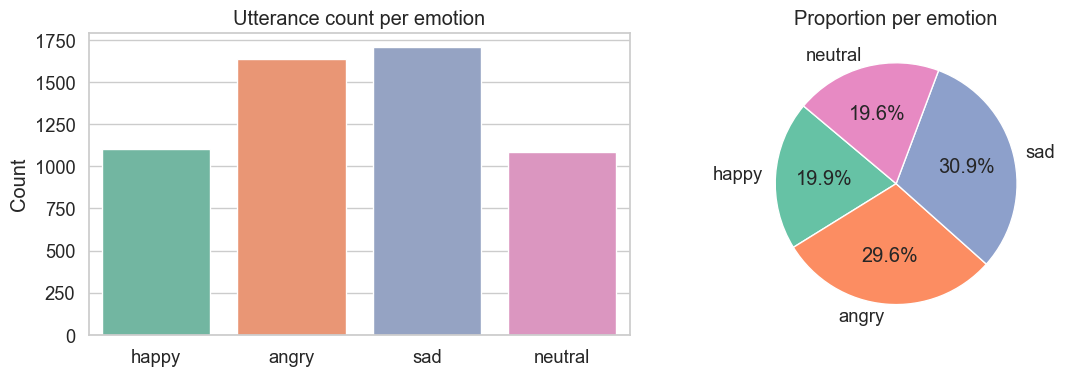

In [8]:
counts = df_unique['emotion'].value_counts().reindex(EMOTIONS)
pct    = counts / counts.sum() * 100

print('=== Emotion counts (unique utterances) ===')
for emo, cnt, p in zip(counts.index, counts.values, pct.values):
    print(f'  {emo:<10} {cnt:>5}  ({p:.1f}%)')
print(f'  {"TOTAL":<10} {counts.sum():>5}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(x=EMOTIONS, y=counts.values, ax=axes[0], palette='Set2')
axes[0].set_title('Utterance count per emotion')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=EMOTIONS, autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('Set2', 4))
axes[1].set_title('Proportion per emotion')

plt.tight_layout()
plt.savefig('../results/label_distribution.png', dpi=150)
plt.show()

## 4  Gender distribution

Gender distribution (unique utterances):
  M  2882  (52.1%)
  F  2649  (47.9%)


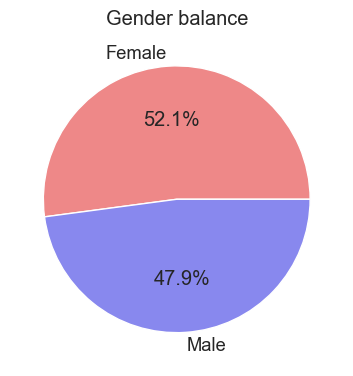

In [9]:
gender_counts = df_unique['gender'].value_counts()
print('Gender distribution (unique utterances):')
for g, cnt in gender_counts.items():
    print(f'  {g}  {cnt}  ({cnt/len(df_unique)*100:.1f}%)')

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(gender_counts.values, labels=['Female', 'Male'],
       autopct='%1.1f%%', colors=[PALETTE['F'], PALETTE['M']])
ax.set_title('Gender balance')
plt.tight_layout()
plt.savefig('../results/gender_distribution.png', dpi=150)
plt.show()

## 5  Emotion × gender cross-tabulation

In [10]:
crosstab = pd.crosstab(df_unique['emotion'], df_unique['gender'],
                        rownames=['Emotion'], colnames=['Gender'])
crosstab = crosstab.reindex(EMOTIONS)
print(crosstab)
print()

# Within-gender percentages
crosstab_pct = crosstab.div(crosstab.sum(axis=0), axis=1) * 100
print('% within each gender:')
print(crosstab_pct.round(1))

Gender     F    M
Emotion          
happy    589  514
angry    770  866
sad      733  975
neutral  557  527

% within each gender:
Gender      F     M
Emotion            
happy    22.2  17.8
angry    29.1  30.0
sad      27.7  33.8
neutral  21.0  18.3


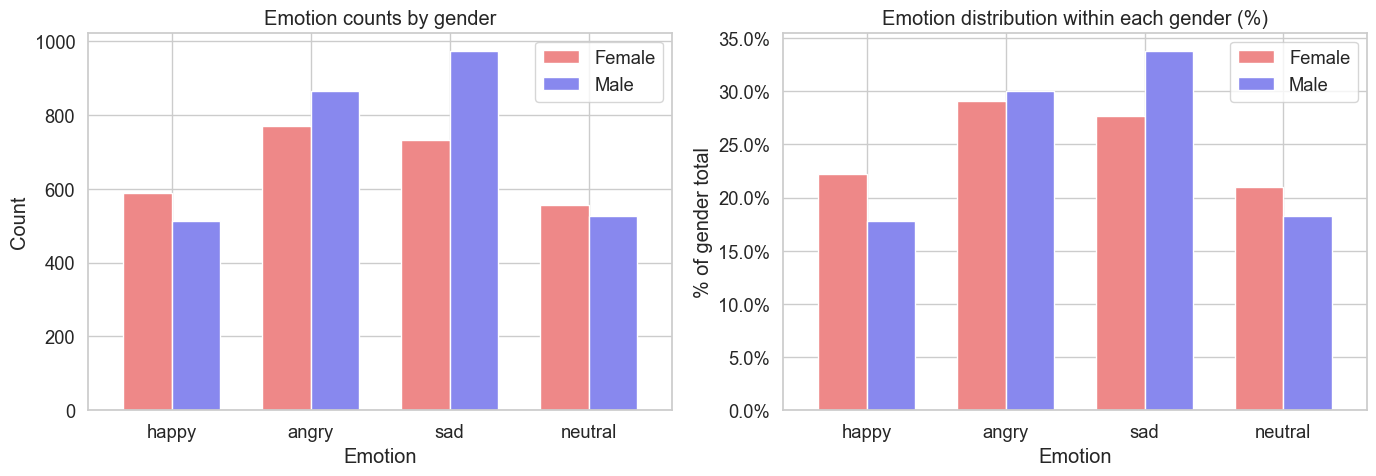

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
crosstab.plot(kind='bar', ax=axes[0], color=[PALETTE['F'], PALETTE['M']],
              edgecolor='white', width=0.7)
axes[0].set_title('Emotion counts by gender')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(EMOTIONS, rotation=0)
axes[0].legend(['Female', 'Male'])

# Within-gender percentages
crosstab_pct.plot(kind='bar', ax=axes[1], color=[PALETTE['F'], PALETTE['M']],
                  edgecolor='white', width=0.7)
axes[1].set_title('Emotion distribution within each gender (%)')
axes[1].set_ylabel('% of gender total')
axes[1].set_xticklabels(EMOTIONS, rotation=0)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].legend(['Female', 'Male'])

plt.tight_layout()
plt.savefig('../results/emotion_by_gender.png', dpi=150)
plt.show()

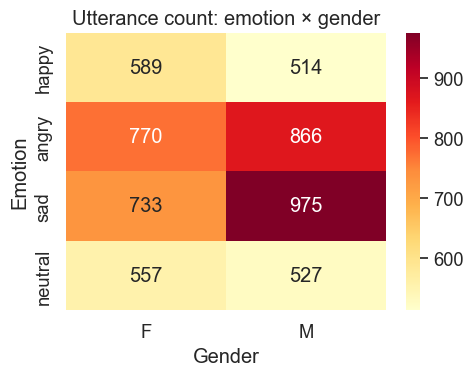

In [12]:
# Heatmap of counts
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(crosstab, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_title('Utterance count: emotion × gender')
plt.tight_layout()
plt.savefig('../results/emotion_gender_heatmap.png', dpi=150)
plt.show()

## 6  Per-fold label distribution (check consistency across folds)

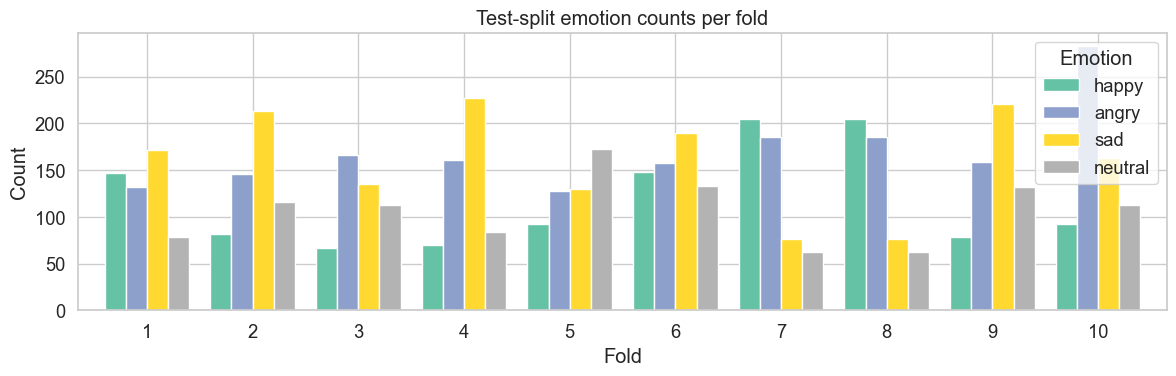


Test-set size per fold:
fold
1     528
2     557
3     481
4     542
5     522
6     629
7     528
8     528
9     590
10    651


In [13]:
# For each fold, look at the TEST split only (the held-out set)
tst_dfs = []
for fold in range(1, N_FOLDS + 1):
    df_tst = load_fold_split(fold, 'tst')
    df_tst['fold'] = fold
    tst_dfs.append(df_tst)
df_tst_all = pd.concat(tst_dfs, ignore_index=True)

fold_counts = df_tst_all.groupby(['fold', 'emotion']).size().unstack(fill_value=0)
fold_counts = fold_counts.reindex(columns=EMOTIONS)

fig, ax = plt.subplots(figsize=(12, 4))
fold_counts.plot(kind='bar', ax=ax, width=0.8, colormap='Set2')
ax.set_title('Test-split emotion counts per fold')
ax.set_ylabel('Count')
ax.set_xlabel('Fold')
ax.set_xticklabels(range(1, N_FOLDS + 1), rotation=0)
ax.legend(title='Emotion', loc='upper right')
plt.tight_layout()
plt.savefig('../results/per_fold_distribution.png', dpi=150)
plt.show()

print('\nTest-set size per fold:')
print(fold_counts.sum(axis=1).to_string())

## 7  Feature file statistics

In [14]:
feature_files = {
    'Audio (ComParE)'  : ROOT / 'A/comparE.h5',
    'Video (DenseFace)': ROOT / 'V/denseface.h5',
    'Text (BERT-large)': ROOT / 'L/bert_large.h5',
}

for name, path in feature_files.items():
    with h5py.File(path, 'r') as f:
        keys = list(f.keys())
        shapes = [f[k].shape for k in keys[:200]]  # sample for speed
    n_frames_list = [s[0] for s in shapes]
    feat_dim = shapes[0][1] if shapes else '?'
    print(f'{name}')
    print(f'  Utterances: {len(keys):,}')
    print(f'  Feature dim: {feat_dim}')
    print(f'  Frames per utt (first 200): min={min(n_frames_list)}, '
          f'max={max(n_frames_list)}, mean={np.mean(n_frames_list):.1f}')
    print()

Audio (ComParE)
  Utterances: 5,531
  Feature dim: 130
  Frames per utt (first 200): min=8, max=291, mean=43.4

Video (DenseFace)
  Utterances: 5,531
  Feature dim: 342
  Frames per utt (first 200): min=50, max=50, mean=50.0

Text (BERT-large)
  Utterances: 5,531
  Feature dim: 1024
  Frames per utt (first 200): min=22, max=22, mean=22.0



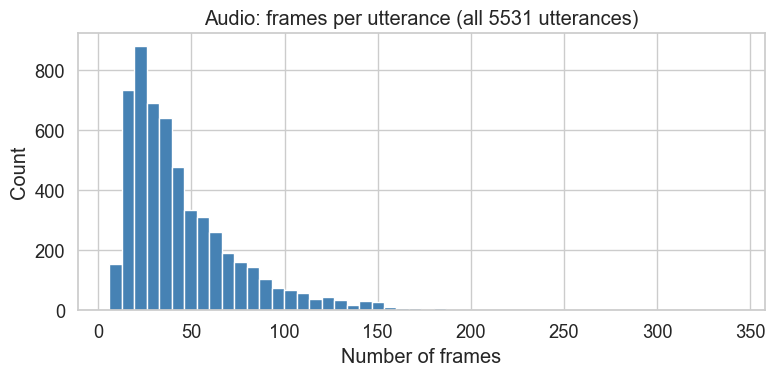

p50: 36  p90: 87  p99: 155


In [15]:
# Sequence-length distribution for audio
with h5py.File(ROOT / 'A/comparE.h5', 'r') as f:
    all_keys = list(f.keys())
    frame_counts = [f[k].shape[0] for k in all_keys]

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(frame_counts, bins=50, color='steelblue', edgecolor='white')
ax.set_title('Audio: frames per utterance (all 5531 utterances)')
ax.set_xlabel('Number of frames')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../results/audio_frame_lengths.png', dpi=150)
plt.show()

print(f'p50: {np.percentile(frame_counts, 50):.0f}  '
      f'p90: {np.percentile(frame_counts, 90):.0f}  '
      f'p99: {np.percentile(frame_counts, 99):.0f}')

## 8  Quick gender-bias sanity check

For each emotion, compare how many utterances are female vs male.  
A large imbalance means a model trained without care could learn gender as a proxy for emotion.

In [16]:
bias_table = df_unique.groupby(['emotion', 'gender']).size().unstack(fill_value=0)
bias_table = bias_table.reindex(EMOTIONS)
bias_table.columns = ['Female', 'Male']
bias_table['F_ratio'] = bias_table['Female'] / (bias_table['Female'] + bias_table['Male'])
bias_table['imbalance'] = (bias_table['F_ratio'] - 0.5).abs()
print(bias_table.round(3))

print('\nMost gender-imbalanced emotion:', bias_table['imbalance'].idxmax())

         Female  Male  F_ratio  imbalance
emotion                                  
happy       589   514    0.534      0.034
angry       770   866    0.471      0.029
sad         733   975    0.429      0.071
neutral     557   527    0.514      0.014

Most gender-imbalanced emotion: sad
